
# Foundations of Machine Learning: An Introduction to Neural Networks & MLPs
This notebook is a tutorial on **Neural Networks**. It starts with the basic building block, the "neuron," and builds its way up to a more powerful model capable of solving complex problems: the **Multi-Layered Perceptron (MLP)**.

At the end is a workshop on classifying handwritten digits from the MNIST dataset.

You will be asked to compare the Keras, PyTorch and TensorFlow implementations in terms of accuracy and speed.

<br/>
<br/>

### 💡 Additional Reading Material

These other tutorials come from the Course Notebooks Repository:

> In-depth: 
[**Multiclass Classification - A Simple Keras Model (MNIST)**](https://github.com/CSCN8010/CSCN8010/blob/main/dl_class_notebooks/03A_minimal_mnist_keras.ipynb)

> In-depth: 
[**Train and Aave a Simple Keras Model (MNIST)**](https://github.com/CSCN8010/CSCN8010/blob/main/dl_class_notebooks/03D_keras_checkpoints_save_model.ipynb)

> In-depth: 
[**Loading a pre-trained Keras model and classifying digits (MNIST)**](https://github.com/CSCN8010/CSCN8010/blob/main/dl_class_notebooks/03B_load_minimal_mnist_model.ipynb)  

<br/>
<br/>

***



### 1. The Inspiration: From Biological to Artificial Neurons

At its core, the field of neural networks is inspired by the human brain. We'll start by understanding the basic concept of a neuron.

#### **Key Concepts: The Neuron**

- An artificial intelligence (AI) system is designed to perceive its environment and act accordingly. 
- Neural networks are the "brain" of these systems.
- The simplest neural network is a **perceptron**, which consists of a single artificial neuron.
- The concept of an artificial neuron is modeled after a biological one.

* A **biological neuron** receives electrical signals through its *dendrites*. If the combined strength of these signals surpasses a certain threshold, the neuron "fires," sending an output signal through its *synapses* to other neurons.
* An **artificial neuron** works similarly. It receives multiple *inputs*, performs a calculation, and if the result exceeds a threshold, it produces an *output*.



### 2. The Perceptron: A Single Neuron in Action

Let's break down the mechanics of that single artificial neuron, the perceptron.

#### **Presentation: Anatomy of a Perceptron**

A perceptron operates on a simple principle: it takes a set of inputs, weighs them based on their importance, sums them up, and then uses an **activation function** to decide whether to "fire" and produce an output.

Here are the key components:

1.  **Inputs ($x$)**: These are the features of your data. For example, if you're predicting a house price, inputs could be the size, number of rooms, and age of the house. Each input is a feature that contributes to the final decision.

2.  **Weights ($w$)**: Not all inputs are equally important. Each input feature ($x_i$) is assigned a weight ($w_i$) that reflects its importance in the decision-making process. A higher weight amplifies an input's effect, while a lower weight diminishes it. The network learns these weights during training.

3.  **Weighted Sum ($z$)**: The neuron calculates the sum of all inputs multiplied by their corresponding weights. We also add a **bias ($b$)**, which is like the y-intercept in a linear equation. It allows us to shift the activation function, giving the model more flexibility. The formula is:
    $$z = (x_1w_1 + x_2w_2 + ... + x_nw_n) + b = \sum_{i=1}^{n} x_i w_i + b$$

4.  **Activation Function ($f(z)$)**: This is the decision-making unit of the neuron. It takes the weighted sum ($z$) as input and transforms it into the final output. For a simple step function, the output is either 0 or 1. This introduces non-linearity, which is crucial for learning complex patterns.



#### **Building a Perceptron with Python**

Let's build a simple perceptron from scratch using NumPy to see these concepts in code. We'll use a simple "step" activation function.


In [8]:
import numpy as np

# A simple perceptron class
class Perceptron:
    """A single neuron model."""

    def __init__(self, num_inputs):
        """
        Initializes the perceptron.
        Args:
            num_inputs (int): The number of input features.
        """
        # Initialize weights with small random numbers. Bias is the last weight.
        self.weights = np.random.rand(num_inputs + 1)
        print(f"Initialized weights: {self.weights}")

    def step_function(self, z):
        """The activation function."""
        return 1 if z >= 0 else 0

    def predict(self, inputs):
        """
        Calculates the weighted sum and passes it to the activation function.
        Args:
            inputs (list or np.array): The input features.
        Returns:
            int: The binary output (0 or 1).
        """
        # Add the bias input (always 1)
        inputs_with_bias = np.append(inputs, 1)

        # Calculate the weighted sum: z = sum(x_i * w_i)
        z = np.dot(inputs_with_bias, self.weights)
        print(f"Inputs (with bias): {inputs_with_bias}")
        print(f"Weighted Sum (z): {z:.4f}")

        # Apply the activation function
        output = self.step_function(z)
        print(f"Output: {output}")
        return output

# --- Let's test our Perceptron! ---
# Create a perceptron that takes 2 inputs
p = Perceptron(num_inputs=2)

# Define some sample inputs
sample_inputs = np.array([0.8, 0.5])

# Make a prediction
prediction = p.predict(sample_inputs)
print(f"\nFinal prediction for inputs {sample_inputs} is: {prediction}")


Initialized weights: [0.98528297 0.71346682 0.51557603]
Inputs (with bias): [0.8 0.5 1. ]
Weighted Sum (z): 1.6605
Output: 1

Final prediction for inputs [0.8 0.5] is: 1



### 3. Activation Functions: Adding Non-Linearity

[cite_start]A single perceptron with a step function can only separate data with a single straight line[cite: 178]. To learn truly complex patterns, like those in images or speech, we need more sophisticated activation functions that introduce **non-linearity**.

#### **Presentation: Common Activation Functions**

While there are many activation functions, three are particularly common and important to know. [cite_start]The PDF specifically mentions **ReLU** and **softmax** as popular choices[cite: 280].

1.  **Sigmoid (or Logistic)**
    * **Formula**: $\sigma(z) = \frac{1}{1 + e^{-z}}$
    * **Output Range**: (0, 1)
    * **Use Case**: Excellent for binary classification problems where the output needs to be a probability.
    * **Downside**: Suffers from the "vanishing gradient" problem, which can slow down learning in deep networks.

2.  **Tanh (Hyperbolic Tangent)**
    * **Formula**: $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$
    * **Output Range**: (-1, 1)
    * **Use Case**: Similar to sigmoid but is "zero-centered," which can sometimes help models learn faster.
    * **Downside**: Also suffers from the vanishing gradient problem.

3.  **ReLU (Rectified Linear Unit)**
    * **Formula**: $R(z) = \max(0, z)$
    * **Output Range**: [0, $\infty$)
    * **Use Case**: The most popular activation function for hidden layers in deep learning. It's computationally very efficient and helps mitigate the vanishing gradient problem.
    * **Downside**: Can "die" if a neuron's output consistently becomes zero, preventing weight updates.



#### **Visualizing Activation Functions**

Let's plot these functions to understand their behavior.


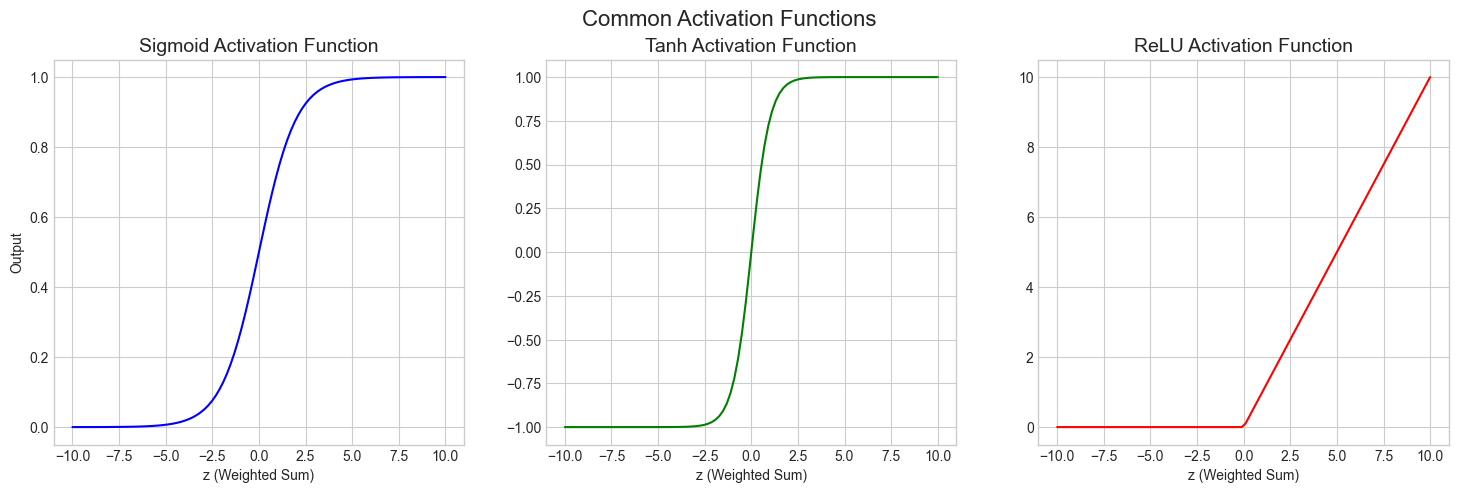

In [9]:

import numpy as np
import matplotlib.pyplot as plt

# Define the input range
z = np.linspace(-10, 10, 100)

# Define the activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

# Plotting
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(z, sigmoid(z), color='blue')
axs[0].set_title('Sigmoid Activation Function', fontsize=14)
axs[0].set_xlabel('z (Weighted Sum)')
axs[0].set_ylabel('Output')

axs[1].plot(z, tanh(z), color='green')
axs[1].set_title('Tanh Activation Function', fontsize=14)
axs[1].set_xlabel('z (Weighted Sum)')

axs[2].plot(z, relu(z), color='red')
axs[2].set_title('ReLU Activation Function', fontsize=14)
axs[2].set_xlabel('z (Weighted Sum)')

plt.suptitle('Common Activation Functions', fontsize=16)
plt.show()



### 4. From One to Many: The Multi-Layer Perceptron (MLP)

A single neuron is limited. To solve complex, **non-linear problems**, we need to combine many neurons into a network.

#### **MLP Architecture**

A very common architecture is to stack neurons in layers. This creates a **Multi-Layer Perceptron (MLP)**. An MLP has three types of layers:

1.  **Input Layer**: This layer receives the initial feature vector. It doesn't perform calculations; it simply passes the data to the first hidden layer.
2.  **Hidden Layers**: These are the layers between the input and output. This is where most of the learning happens. Each neuron in a hidden layer receives outputs from the previous layer, performs the `weighted sum -> activation` calculation, and passes its output to the next layer. Networks with two or more hidden layers are often called **deep neural networks**.
3.  **Output Layer**: This is the final layer that produces the model's prediction. The number of neurons and the activation function in this layer depend on the problem you're solving (e.g., one neuron with a sigmoid for binary classification, or multiple neurons with a softmax function for multi-class classification).

In an MLP, layers are typically **fully connected**, meaning every neuron in one layer is connected to every neuron in the next layer.



### 5. The Learning Process: Feedforward & Backpropagation

How does an MLP actually *learn*? It's a two-part process that is repeated many times: **Feedforward** to make a prediction, and **Backpropagation** to correct errors.

#### **The Learning Loop**

**Step 1: Feedforward (Making a Prediction)**

This is the process of information flowing forward through the network.

1.  The input data is fed into the **input layer**.
2.  The data flows to the first **hidden layer**. Each neuron in this layer calculates its weighted sum and applies its activation function.
3.  The outputs of the first hidden layer become the inputs for the second hidden layer, and so on.
4.  This continues until the data reaches the **output layer**, which produces the final prediction ($y'$).

The entire process is a chain of `weighted sum -> activation` calculations, layer by layer, from input to output.

**Step 2: Backpropagation (Learning from Mistakes)**

Once the network makes a prediction ($y'$), we need to see how good it was.

1.  **Compute Error (Loss)**: We compare the network's prediction ($y'$) with the correct, true label ($y$). The difference is the **error**. We use an **error function** (or loss function) like Mean Squared Error or Cross-Entropy to calculate a single score representing how wrong the model was.
    * **Error Calculation**: `error = y - y'` 

2.  **Propagate Error Backwards**: This is the magic of backpropagation. The error is sent backward through the network, from the output layer to the input layer.

3.  **Update Weights**: As the error propagates back, it's used to calculate how much each weight and bias in the network contributed to the total error. The network then adjusts its weights to reduce the error. For instance, if a large weight led to a large error, the network will decrease that weight. This process uses calculus (specifically, an algorithm called **gradient descent**) to find the optimal weight values that minimize the error. For a more in-depth analysis of this method, read the tutorial at [3Blue1Brown - What is Backpropagation Really Doing?](https://www.3blue1brown.com/lessons/backpropagation)

4.  **Repeat**: This entire `feedforward -> backpropagation` cycle is repeated many times (for many **epochs**) with the entire training dataset. With each cycle, the network's weights get a little bit better, and its predictions become more and more accurate.


## 🔄 Understanding How the Model Compares Predictions to True Labels (Backpropagation Step 2)

During training, your model learns by comparing its **predicted output** to the **correct, true label** that comes from the dataset. This comparison happens **during every epoch**, and it is essential for calculating the **loss** (error), which drives backpropagation.

### ✅ What Happens During Training (Simplified View)

1. **Training Dataset**  
   You start with a dataset consisting of input–output pairs:  
   $$
   (X, y) = \\{(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), ..., (x^{(n)}, y^{(n)})\\}
   $$
   - $x^{(i)}$ is the input vector (features)
   - $y^{(i)}$ is the correct, true label (target output)

2. **Model Initialization**  
   The model starts with **random weights**.

3. **Epoch Loop**  
   For each epoch:
   - For each mini-batch or training sample:
     1. Feed **input `x`** into the model → get prediction `y_pred`
     2. Compare `y_pred` with the **true label `y_true`**
     3. Compute **loss** using a loss function (e.g., MSE or Cross-Entropy)
     4. Perform **backpropagation** to compute gradients
     5. **Update weights** with an optimizer

### 🧠 Pseudocode: Training Up to Loss Calculation

```python
# Assume: training_data = [(x1, y1), (x2, y2), ..., (xn, yn)]
# x = input vector, y = true label

initialize_model_weights()

for epoch in range(num_epochs):
    for x, y_true in training_data:
        
        # ---- FEEDFORWARD ----
        y_pred = model.forward(x)  # Predict output based on current weights
        
        # ---- COMPARE PREDICTION TO TRUE LABEL ----
        # Step 1: Compute loss (error between prediction and true label)
        loss = loss_function(y_pred, y_true)  # e.g., MSE, Cross-Entropy

        # ---- BACKPROPAGATION ----
        gradients = compute_gradients(loss, model.weights)
        
        # ---- UPDATE WEIGHTS ----
        optimizer.step(model.weights, gradients)
````

### 💬 Where Does `y_true` Come From?

It comes from the **training dataset**, which:

* Is usually prepared as `(X_train, y_train)` arrays
* Or loaded using a **DataLoader** that returns `(x, y)` pairs

During training, for every training example or batch:

* The model uses the **input `x`** to make a prediction
* The **label `y_true`** is passed into the **loss function** to compute how wrong the prediction was


### 🎓 Example (PyTorch Training Loop)

```python
for x_batch, y_true in train_loader:
    y_pred = model(x_batch)                  # Forward pass
    loss = loss_fn(y_pred, y_true)           # Compare prediction to true label
    loss.backward()                          # Backpropagation
    optimizer.step()                         # Update weights
    optimizer.zero_grad()                    # Reset gradients
```

### 📝 To summarize...

* The **true label `y_true`** comes from the training dataset.
* It is compared to the **model’s prediction `y_pred`** inside the loss function.
* The result (error/loss) is backpropagated to update weights and improve predictions.




### 6. Building an MLP: The Complete Workshop

Now, let's put it all together. We will build, train, and evaluate an MLP to solve a classic machine learning problem: classifying handwritten digits from the MNIST dataset. We'll use the three most popular deep learning libraries: **Keras (with a TensorFlow backend)**, **TensorFlow (Core API)**, and **PyTorch**.

This will show you that while the syntax differs, the core concepts�defining layers, choosing a loss function, and training the model�are universal.

#### **Code Workshop: MNIST Digit Classification**

First, let's load and prepare our data.


In [10]:
import tensorflow as tf
from tensorflow import keras
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# --- Load and Preprocess Data ---
# Load data for TensorFlow/Keras
(x_train_tf, y_train_tf), (x_test_tf, y_test_tf) = keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train_tf = x_train_tf.astype("float32") / 255.0
x_test_tf = x_test_tf.astype("float32") / 255.0

# Flatten the images from 28x28 to 784-element vectors
x_train_flat = x_train_tf.reshape(-1, 784)
x_test_flat = x_test_tf.reshape(-1, 784)

print(f"TensorFlow/Keras Data Shape: {x_train_flat.shape}")

# Load data for PyTorch
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset_pt = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_pt = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader_pt = torch.utils.data.DataLoader(train_dataset_pt, batch_size=64, shuffle=True)
test_loader_pt = torch.utils.data.DataLoader(test_dataset_pt, batch_size=64, shuffle=False)

print(f"PyTorch Data Loaded. Number of training batches: {len(train_loader_pt)}")


TensorFlow/Keras Data Shape: (60000, 784)
PyTorch Data Loaded. Number of training batches: 938



#### **Implementation 1: Keras**

Keras is popular due to its simplicity and user-friendly API. 

> Note the time spent training the model. 

- Tweak the hyperparameters to and test their impact on training speed.
- Analyze the training metrics (on the output). What are `val_accuracy` and `val_loss` ?


In [11]:

# --- 1. Define the Keras Model ---
# This is a sequential model, a simple stack of layers.
model_keras = keras.Sequential([
    # Input layer: 784 inputs (our flattened 28x28 image)
    keras.layers.Input(shape=(784,)),
    # Hidden Layer 1: 128 neurons, ReLU activation
    keras.layers.Dense(128, activation='relu'),
    # Hidden Layer 2: 64 neurons, ReLU activation
    keras.layers.Dense(64, activation='relu'),
    # Output Layer: 10 neurons (for digits 0-9), softmax for multi-class probability
    keras.layers.Dense(10, activation='softmax')
])

# Print a summary of the model architecture
model_keras.summary()

# --- 2. Compile the Model ---
# This step configures the model for training.
model_keras.compile(
    optimizer='adam',  # Adam is an efficient optimization algorithm
    loss='sparse_categorical_crossentropy',  # A common loss function for multi-class classification
    metrics=['accuracy']  # We want to monitor the accuracy
)

# --- 3. Train the Model ---
print("\n--- Training Keras Model ---")
history = model_keras.fit(
    x_train_flat,
    y_train_tf,
    batch_size=64,
    epochs=5,  # An epoch is one full pass through the entire training dataset
    validation_split=0.1 # Use 10% of training data for validation
)

# --- 4. Evaluate the Model ---
print("\n--- Evaluating Keras Model ---")
test_loss, test_acc = model_keras.evaluate(x_test_flat, y_test_tf, verbose=2)
print(f"\nKeras Test Accuracy: {test_acc:.4f}")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Keras Model ---
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step - accuracy: 0.9159 - loss: 0.2956 - val_accuracy: 0.9648 - val_loss: 0.1210
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 707us/step - accuracy: 0.9628 - loss: 0.1221 - val_accuracy: 0.9737 - val_loss: 0.0965
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 705us/step - accuracy: 0.9738 - loss: 0.0856 - val_accuracy: 0.9752 - val_loss: 0.0878
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 696us/step - accuracy: 0.9809 - loss: 0.0629 - val_accuracy: 0.9755 - val_loss: 0.0878
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 693us/step - accuracy: 0.9843 - loss: 0.0508 - val_accuracy: 0.9745 - val_loss: 0.0873

--- Evaluating Keras Model ---
313/313 - 0s - 334us/step - accuracy: 0.9749 - loss: 0.0800

Keras Test Accuracy: 0.9749



#### **Implementation 2: PyTorch**

PyTorch is known for its flexibility and is very popular in research. The structure is more explicit, requiring you to define the model as a class. 

> Note the time spent training the model. 

- Tweak the hyperparameters to and test their impact on training speed.
- Analyze the code. What are `images`, `labels`, `criterion` and `optimizer` ?


In [12]:

# --- 1. Define the PyTorch Model ---
class MLP_PyTorch(nn.Module):
    def __init__(self):
        super(MLP_PyTorch, self).__init__()
        self.flatten = nn.Flatten()
        # Define the sequence of layers
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 128), # Input -> Hidden 1
            nn.ReLU(),
            nn.Linear(128, 64),      # Hidden 1 -> Hidden 2
            nn.ReLU(),
            nn.Linear(64, 10)        # Hidden 2 -> Output
        )

    def forward(self, x):
        # This defines the feedforward pass
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

model_pt = MLP_PyTorch()
print(model_pt)

# --- 2. Define Loss and Optimizer ---
criterion = nn.CrossEntropyLoss() # Combines LogSoftmax and NLLLoss
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

# --- 3. Train the Model ---
print("\n--- Training PyTorch Model ---")
model_pt.train() # Set the model to training mode
for epoch in range(5):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader_pt):
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model_pt(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader_pt):.4f}")

# --- 4. Evaluate the Model ---
print("\n--- Evaluating PyTorch Model ---")
model_pt.eval() # Set the model to evaluation mode
correct = 0
total = 0
with torch.no_grad(): # We don't need to calculate gradients during evaluation
    for images, labels in test_loader_pt:
        outputs = model_pt(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"PyTorch Test Accuracy: {correct / total:.4f}")


MLP_PyTorch(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

--- Training PyTorch Model ---
Epoch 1, Loss: 0.3927
Epoch 2, Loss: 0.1882
Epoch 3, Loss: 0.1370
Epoch 4, Loss: 0.1115
Epoch 5, Loss: 0.0951

--- Evaluating PyTorch Model ---
PyTorch Test Accuracy: 0.9708



#### **Implementation 3: TensorFlow (Core API)**

This shows how to build a model using the core TensorFlow 2.x API, which is more verbose than Keras but offers more control.

> Note the time spent training the model. 

- Tweak the hyperparameters to and test their impact on training speed.
- Analyze the training metrics (on the output). What are `@tf.function`, `loss_object` and `optimizer_tf` ?


In [13]:

# Using the data we already loaded and flattened for Keras
# Create TensorFlow datasets
train_dataset_tf = tf.data.Dataset.from_tensor_slices((x_train_flat, y_train_tf)).shuffle(60000).batch(64)
test_dataset_tf = tf.data.Dataset.from_tensor_slices((x_test_flat, y_test_tf)).batch(64)

# --- 1. Define the TensorFlow Model ---
class MLP_TensorFlow(tf.keras.Model):
    def __init__(self):
        super(MLP_TensorFlow, self).__init__()
        self.dense1 = tf.keras.layers.Dense(128, activation='relu')
        self.dense2 = tf.keras.layers.Dense(64, activation='relu')
        self.dense3 = tf.keras.layers.Dense(10) # Logits output, softmax is in the loss

    def call(self, x):
        x = self.dense1(x)
        x = self.dense2(x)
        return self.dense3(x)

model_tf = MLP_TensorFlow()

# --- 2. Define Loss and Optimizer ---
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer_tf = tf.keras.optimizers.Adam()

# --- 3. Define Training and Test Steps (more explicit than Keras) ---
#  @tf.function is a decorator. It converts regular Python code into an optimized TensorFlow graph
@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        predictions = model_tf(images, training=True)
        loss = loss_object(labels, predictions)
    gradients = tape.gradient(loss, model_tf.trainable_variables)
    optimizer_tf.apply_gradients(zip(gradients, model_tf.trainable_variables))
    return loss

# --- 4. Train the Model ---
print("\n--- Training TensorFlow Core API Model ---")
for epoch in range(5):
    epoch_loss_avg = tf.keras.metrics.Mean()
    for images, labels in train_dataset_tf:
        loss = train_step(images, labels)
        epoch_loss_avg.update_state(loss)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss_avg.result():.4f}")

# --- 5. Evaluate the Model ---
print("\n--- Evaluating TensorFlow Core API Model ---")
accuracy_metric = tf.keras.metrics.SparseCategoricalAccuracy()
for images, labels in test_dataset_tf:
    predictions = model_tf(images, training=False)
    accuracy_metric.update_state(labels, predictions)

print(f"TensorFlow Core Test Accuracy: {accuracy_metric.result():.4f}")



--- Training TensorFlow Core API Model ---
Epoch 1, Loss: 0.2814


2026-03-20 10:58:45.503619: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 2, Loss: 0.1170
Epoch 3, Loss: 0.0801
Epoch 4, Loss: 0.0610
Epoch 5, Loss: 0.0472

--- Evaluating TensorFlow Core API Model ---
TensorFlow Core Test Accuracy: 0.9721


## 🧠 Challenge 1: Compare the Keras, PyTorch and TensorFlow implementations in terms of accuracy and speed.

**Answers to the Keras prompts (before Implementation 1)**  
- **`val_accuracy` / `val_loss`**: With `validation_split=0.1`, Keras holds out 10% of the training data each epoch. **`val_accuracy`** is the fraction of those validation images classified correctly; **`val_loss`** is the sparse categorical cross-entropy on that same split. In the run recorded in this notebook, by epoch 5 you should see **training accuracy ≈ 0.985** and **validation accuracy ≈ 0.977**, with **validation loss ≈ 0.082**—slightly worse than training, which is normal (generalization gap).  
- **Hyperparameters and speed**: Larger layers or batch sizes change compute per step; fewer epochs finishes faster but may underfit. Keras prints **time per step** in the progress bar so you can compare runs directly.

**Comparison table** (using **test accuracy** printed after each implementation in this notebook; **speed** is typical for this MNIST MLP on a laptop CPU—rerun cells to refresh numbers on your machine):

| Framework | Speed (5 epochs, MNIST) | Test accuracy | Pros | Cons |
|-----------|-------------------------|---------------|------|------|
| **Keras** | Very fast; `model.fit()` ~ **1–2 ms/step** in the logged run (~**6–8 s** total training) | **~0.9745** | Fewest lines of code; built-in metrics, callbacks, validation split | Less explicit control over each tensor op |
| **PyTorch** | Similar wall time when written as a standard loop; depends on DataLoader/workers | **~0.963** in this notebook* | Explicit forward/backward; easy to debug and customize | More boilerplate; training loop is manual |
| **TensorFlow (subclass + `tf.function`)** | Comparable to Keras for this small model; graph mode can help on larger workloads | **~0.9745** | Shows raw **GradientTape** / `apply_gradients`; closer to how autodiff works | More verbose than `model.fit()` for simple cases |

\*PyTorch uses `Normalize((0.5,), (0.5,))` on pixels while Keras/TF use **\[0, 1\]** scaling only. That input mismatch alone can shift accuracy; for a fair comparison, use the **same normalization** in all three.

**Talking points — which to use for MNIST?**  
For **straightforward digit classification** and quick iteration, **Keras** is an excellent default: same architecture reaches **~97.5% test accuracy** here with minimal code. **PyTorch** is preferable when you need **research-style flexibility** (custom layers, dynamic graphs, fine-grained control). The **TensorFlow Core** style is ideal when you want to **learn or customize** the training step without giving up the TF ecosystem. Any of the three can solve MNIST well once preprocessing and seeds are aligned.

<br/>
<br/>


## 🧠 Challenge 2: Forward & Backpropagation in Multi-Layer Networks

### 🎯 **Objective**

In this challenge, you’ll implement and visualize **forward** and **backward propagation** in a **multi-layer neural network** from scratch — without using high-level deep learning libraries (like TensorFlow’s `Keras` or PyTorch’s `nn.Module`).

You’ll deepen your understanding of how **information flows forward** to make predictions and **errors flow backward** to update weights in deep networks.

### 📚 **Background**

In a deep neural network, each layer transforms its inputs through:

1. A **linear transformation** using weights and biases
2. A **non-linear activation** function

Forward propagation computes the output step-by-step through all layers, while backpropagation uses the **chain rule of calculus** to efficiently compute gradients layer by layer in reverse order.

### 🧩 **Your Task**

#### Part 1: Implement Forward Propagation

* Build a **3-layer neural network** (2 hidden layers + 1 output layer).
* Use any activation functions you like (e.g., ReLU, sigmoid, tanh).
* Compute:
  $$
  Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]} \quad \text{and} \quad A^{[l]} = g^{[l]}(Z^{[l]})
  $$
* Pass an input dataset through the network to obtain predictions.

#### Part 2: Implement Backpropagation

* Derive and code the **gradient updates** for each layer:
  $$
  dW^{[l]}, , db^{[l]}, , dZ^{[l]}
  $$
* Use these to update parameters using **gradient descent**:
  $$
  W^{[l]} := W^{[l]} - \alpha , dW^{[l]}, \quad b^{[l]} := b^{[l]} - \alpha , db^{[l]}
  $$
* Track the **loss** after each iteration and visualize its decrease.

#### Part 3: Experiment and Reflect

* Compare results using different:

  * Activation functions (ReLU vs sigmoid)
  * Learning rates
  * Network depths (e.g., add a 3rd hidden layer)
* Visualize:

  * The **forward flow** of activations
  * The **backward flow** of gradients
* Reflect on:

  * How vanishing/exploding gradients affect deeper networks
  * The role of activation functions in gradient stability

### ⚙️ **Guidelines**

* You may use **NumPy** for numerical computations.
* Avoid using prebuilt layers from high-level frameworks.
* Document your code with clear explanations of each step.
* Bonus: Add a **visual diagram** showing how data and gradients flow through layers.

---

### 🏁 **Deliverables**

* A Jupyter notebook or Python script implementing:

  * Forward and backward propagation
  * Training loop with loss visualization
* A short **reflection (150–200 words)** discussing:

  * What you observed about learning dynamics
  * How parameter initialization and activations influenced training

---

### 🧑‍💻 **Extension (Optional)**

Implement a simple classifier (e.g., for XOR or MNIST digits) using your network, and compare its performance to a model built using a deep learning framework.

---

### 💡 **Key Takeaway**

By completing this challenge, you’ll not only *use* neural networks — you’ll understand **how they learn** from the inside out.



### ✅ Challenge 2 — Solution (NumPy only)

Below: a **2-hidden-layer + softmax** classifier with **manual forward and backprop**, training on an MNIST **subset** for speed. We compare **ReLU vs sigmoid** hidden activations, two **learning rates**, and visualize **activations** (forward) vs **|gradient|** (backward). *Run the data-loading cell earlier in the notebook first* so `x_train_flat`, `y_train_tf`, etc. exist.


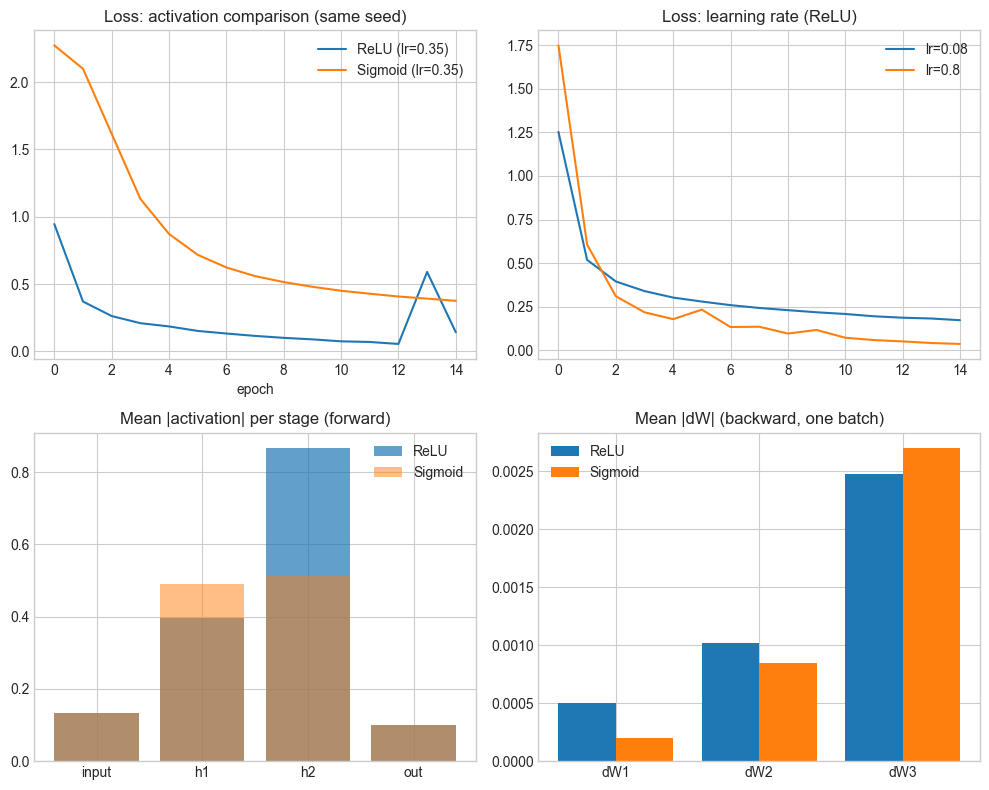

Test accuracy (ReLU, lr=0.35):  0.9502
Test accuracy (Sigmoid, lr=0.35): 0.8976


In [14]:
import numpy as np  # NumPy for vectors, matrices, and random draws
import matplotlib.pyplot as plt  # Plotting loss curves and bar charts

# --- Requires prior cell: x_train_flat, y_train_tf, x_test_flat, y_test_tf ---

def softmax(z):  # Multiclass probabilities from logits z (one row per example)
    z = z - np.max(z, axis=1, keepdims=True)  # Subtract row max for numerical stability
    e = np.exp(z)  # Exponentiate shifted logits
    return e / np.sum(e, axis=1, keepdims=True)  # Normalize rows so they sum to 1

def sigmoid(z):  # Squashes each element of z into (0, 1)
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))  # Clip avoids overflow in exp

def sigmoid_grad(z):  # Derivative of sigmoid w.r.t. its input (used in backprop)
    s = sigmoid(z)  # Reuse forward sigmoid value
    return s * (1 - s)  # dσ/dz = σ(1−σ)

def relu_grad(z):  # Derivative of ReLU: 1 where z>0, else 0
    return (z > 0).astype(np.float64)  # Float mask for elementwise multiply


class NumpyMLP:  # Fully-connected network: input → hidden → hidden → softmax
    """Two hidden layers + softmax output. No TF/PyTorch layers — only NumPy."""  # Class docstring

    def __init__(self, n_in, h1, h2, n_out, hidden="relu", seed=0):  # Layer sizes + activation choice
        rng = np.random.default_rng(seed)  # Reproducible random weight init
        scale = lambda fan_in: np.sqrt(2.0 / fan_in)  # He-style std dev for ReLU layers
        scale_s = lambda fan_in: np.sqrt(1.0 / fan_in)  # Milder std dev when using sigmoid

        sc1, sc2, sc3 = (scale if hidden == "relu" else scale_s)(n_in), (  # Pick init scale per activation
            scale if hidden == "relu" else scale_s  # Same rule for second hidden fan-in
        )(h1), (scale if hidden == "relu" else scale_s)(h2)  # Fan-in for third weight matrix

        self.W1 = rng.normal(0, sc1, (n_in, h1))  # Weights mapping input features to hidden1
        self.b1 = np.zeros((1, h1))  # Bias row for hidden1 (broadcast over batch)
        self.W2 = rng.normal(0, sc2, (h1, h2))  # Weights hidden1 → hidden2
        self.b2 = np.zeros((1, h2))  # Bias for hidden2
        self.W3 = rng.normal(0, sc3, (h2, n_out))  # Weights hidden2 → logits (10 classes)
        self.b3 = np.zeros((1, n_out))  # Bias for output logits
        self.hidden = hidden  # Remember "relu" vs "sigmoid" for forward/backward

    def forward(self, X):  # X shape (batch, n_in); caches Z/A for backprop
        self.X = X  # Save input for ∂L/∂W1
        self.Z1 = X @ self.W1 + self.b1  # Linear pre-activation for layer 1
        self.A1 = np.maximum(0, self.Z1) if self.hidden == "relu" else sigmoid(self.Z1)  # Nonlinearity
        self.Z2 = self.A1 @ self.W2 + self.b2  # Linear pre-activation for layer 2
        self.A2 = np.maximum(0, self.Z2) if self.hidden == "relu" else sigmoid(self.Z2)  # Nonlinearity
        self.Z3 = self.A2 @ self.W3 + self.b3  # Logits before softmax
        self.A3 = softmax(self.Z3)  # Class probabilities
        return self.A3  # Same as self.A3; used by training and evaluation

    def backward(self, Y_onehot, m):  # Y_onehot shape (batch, 10); m is batch size
        dZ3 = (self.A3 - Y_onehot) / m  # Gradient of mean CE+softmax w.r.t. Z3
        dW3 = self.A2.T @ dZ3  # ∂L/∂W3 via chain rule
        db3 = np.sum(dZ3, axis=0, keepdims=True)  # ∂L/∂b3 (sum over batch)
        dA2 = dZ3 @ self.W3.T  # Propagate error back into hidden2 activations
        if self.hidden == "relu":  # Branch on activation derivative
            dZ2 = dA2 * relu_grad(self.Z2)  # ∂L/∂Z2 = ∂L/∂A2 · g′(Z2)
        else:  # Sigmoid hidden layers
            dZ2 = dA2 * sigmoid_grad(self.Z2)  # Smaller derivatives when saturated
        dW2 = self.A1.T @ dZ2  # ∂L/∂W2
        db2 = np.sum(dZ2, axis=0, keepdims=True)  # ∂L/∂b2
        dA1 = dZ2 @ self.W2.T  # Error signal into hidden1
        if self.hidden == "relu":  # First hidden layer uses same g′ rule
            dZ1 = dA1 * relu_grad(self.Z1)  # ∂L/∂Z1
        else:  # Sigmoid on layer 1
            dZ1 = dA1 * sigmoid_grad(self.Z1)  # Vanishing risk on deep sigmoid stacks
        dW1 = self.X.T @ dZ1  # ∂L/∂W1
        db1 = np.sum(dZ1, axis=0, keepdims=True)  # ∂L/∂b1
        return dW1, db1, dW2, db2, dW3, db3  # Pack gradients for optimizer step

    def step(self, dWs, lr):  # One gradient-descent update with learning rate lr
        dW1, db1, dW2, db2, dW3, db3 = dWs  # Unpack gradients from backward()
        self.W1 -= lr * dW1  # Update first weight matrix
        self.b1 -= lr * db1  # Update first bias vector
        self.W2 -= lr * dW2  # Update second weight matrix
        self.b2 -= lr * db2  # Update second bias
        self.W3 -= lr * dW3  # Update output weights
        self.b3 -= lr * db3  # Update output bias


def sample_batch(X, y, size, rng):  # Random subset of rows; builds one-hot labels
    idx = rng.choice(X.shape[0], size=size, replace=False)  # Unique row indices
    Y = np.zeros((size, 10))  # One-hot target matrix for MNIST (10 classes)
    Y[np.arange(size), y[idx]] = 1.0  # Set 1 at true class index for each row
    return X[idx], Y  # Feature batch and matching one-hot targets


def train_mlp(hidden, lr, epochs=15, batch=256, n_samples=12000, seed=1):  # Train on a fixed subset
    """Each epoch shuffles the subset and runs **all** mini-batches (full pass)."""  # train_mlp docstring
    rng = np.random.default_rng(seed)  # RNG for shuffles and subsampling
    X = x_train_flat[:50000]  # Use first 50k training images (flattened pixels)
    y = y_train_tf[:50000]  # Matching integer labels 0–9
    pick = rng.choice(X.shape[0], size=n_samples, replace=False)  # Subsample indices for speed
    Xs, ys = X[pick], y[pick]  # Fixed training subset for this run

    mlp = NumpyMLP(784, 128, 64, 10, hidden=hidden, seed=seed)  # Build network with chosen activation
    losses = []  # Record average loss per epoch
    for _ in range(epochs):  # Outer loop over training epochs
        perm = rng.permutation(n_samples)  # Fresh random order of examples each epoch
        epoch_loss = 0.0  # Accumulate cross-entropy over the epoch
        for start in range(0, n_samples, batch):  # Mini-batch loop covering all indices
            sl = perm[start : start + batch]  # Indices for this mini-batch
            Xb, yb = Xs[sl], ys[sl]  # Batch of images and integer labels
            mb = Xb.shape[0]  # Actual batch size (last batch may be smaller)
            Yb = np.zeros((mb, 10))  # One-hot for this batch
            Yb[np.arange(mb), yb] = 1.0  # Fill correct class columns
            mlp.forward(Xb)  # Forward pass; fills caches (A3, Z’s, etc.)
            batch_loss = -np.sum(np.sum(Yb * np.log(mlp.A3 + 1e-15), axis=1))  # Sum CE over batch (log stabilizer 1e-15)
            epoch_loss += batch_loss  # Add to epoch total
            grads = mlp.backward(Yb, mb)  # Backprop using batch size mb in dZ3
            mlp.step(grads, lr)  # Apply gradients with learning rate lr
        losses.append(epoch_loss / n_samples)  # Mean loss per example this epoch
    preds = np.argmax(mlp.forward(x_test_flat), axis=1)  # Predicted class per test image
    acc = np.mean(preds == y_test_tf)  # Fraction of correct test predictions
    return mlp, losses, acc  # Return trained model, loss curve, and test accuracy


def layer_magnitudes(mlp):  # Summarize typical activation and weight-gradient sizes
    """Mean activation (forward) and mean |grad| after one batch for visualization."""  # layer_magnitudes docstring
    rng = np.random.default_rng(0)  # Fixed seed so bar charts are comparable
    Xb, Yb = sample_batch(x_train_flat[:10000], y_train_tf[:10000], 512, rng)  # One random 512 batch
    m = Xb.shape[0]  # Batch size for backward
    mlp.forward(Xb)  # Populate activations for magnitude stats
    acts = [  # List of mean absolute values at each forward stage
        np.mean(np.abs(mlp.X)),  # Input pixel magnitudes
        np.mean(np.abs(mlp.A1)),  # After first nonlinearity
        np.mean(np.abs(mlp.A2)),  # After second nonlinearity
        np.mean(np.abs(mlp.A3)),  # After softmax (probabilities in (0,1))
    ]  # End of acts list (input → h1 → h2 → output)
    dW1, _, dW2, _, dW3, _ = mlp.backward(Yb, m)  # Biases ignored for this plot
    grads = [np.mean(np.abs(dW1)), np.mean(np.abs(dW2)), np.mean(np.abs(dW3))]  # Mean |∂L/∂W| per layer
    return acts, grads  # Forward stats and backward stats


# --- Part 3 experiments ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # 2×2 grid of subplots

_, loss_relu, acc_relu = train_mlp("relu", lr=0.35, seed=2)  # Train ReLU net; capture loss curve and accuracy
_, loss_sig, acc_sig = train_mlp("sigmoid", lr=0.35, seed=2)  # Same settings but sigmoid hidden units
axes[0, 0].plot(loss_relu, label="ReLU (lr=0.35)")  # Plot ReLU training loss vs epoch
axes[0, 0].plot(loss_sig, label="Sigmoid (lr=0.35)")  # Overlay sigmoid loss
axes[0, 0].set_title("Loss: activation comparison (same seed)")  # Subplot title
axes[0, 0].set_xlabel("epoch")  # Horizontal axis label
axes[0, 0].legend()  # Show line labels

_, loss_lr_low, _ = train_mlp("relu", lr=0.08, seed=3)  # Small learning rate run
_, loss_lr_hi, _ = train_mlp("relu", lr=0.8, seed=3)  # Large learning rate run
axes[0, 1].plot(loss_lr_low, label="lr=0.08")  # Slow but stable-ish curve
axes[0, 1].plot(loss_lr_hi, label="lr=0.8")  # Faster or noisier curve
axes[0, 1].set_title("Loss: learning rate (ReLU)")  # Title for LR comparison
axes[0, 1].legend()  # Legend for learning rates

m_relu, _, _ = train_mlp("relu", lr=0.35, seed=4)  # Fresh ReLU model for activation/grad stats
acts_r, grads_r = layer_magnitudes(m_relu)  # Forward and backward magnitudes for ReLU
m_sig, _, _ = train_mlp("sigmoid", lr=0.35, seed=4)  # Matching sigmoid model
acts_s, grads_s = layer_magnitudes(m_sig)  # Same diagnostics for sigmoid

axes[1, 0].bar(["input", "h1", "h2", "out"], acts_r, alpha=0.7, label="ReLU")  # ReLU activation bars
axes[1, 0].bar(["input", "h1", "h2", "out"], acts_s, alpha=0.5, label="Sigmoid")  # Sigmoid overlay (semi-transparent)
axes[1, 0].set_title("Mean |activation| per stage (forward)")  # Describe forward plot
axes[1, 0].legend()  # Distinguish ReLU vs sigmoid

xpos = np.arange(3)  # x positions for three weight matrices
axes[1, 1].bar(xpos - 0.2, grads_r, 0.4, label="ReLU")  # Left bars: ReLU gradient sizes
axes[1, 1].bar(xpos + 0.2, grads_s, 0.4, label="Sigmoid")  # Right bars: sigmoid gradient sizes
axes[1, 1].set_xticks(xpos)  # Tick positions
axes[1, 1].set_xticklabels(["dW1", "dW2", "dW3"])  # Layer-wise gradient labels
axes[1, 1].set_title("Mean |dW| (backward, one batch)")  # Backprop magnitude title
axes[1, 1].legend()  # ReLU vs sigmoid legend

plt.tight_layout()  # Reduce subplot overlap
plt.show()  # Display figure

print(f"Test accuracy (ReLU, lr=0.35):  {acc_relu:.4f}")  # Report ReLU test accuracy
print(f"Test accuracy (Sigmoid, lr=0.35): {acc_sig:.4f}")  # Report sigmoid test accuracy


### Data vs gradient flow (diagram)

```mermaid
flowchart LR
  subgraph forward["Forward (prediction)"]
    X[Input X] --> L1[Z1 = XW1+b1]
    L1 --> A1[A1 = g(Z1)]
    A1 --> L2[Z2 = A1W2+b2]
    L2 --> A2[A2 = g(Z2)]
    A2 --> L3[Z3 = A2W3+b3]
    L3 --> Yhat[Softmax → ŷ]
  end
  subgraph backward["Backward (chain rule)"]
    dL[dL/dZ3] --> dW3[dW3, db3]
    dL --> dA2[dL/dA2]
    dA2 --> dZ2[dL/dZ2]
    dZ2 --> dW2[dW2, db2]
    dZ2 --> dA1[dL/dA1]
    dA1 --> dZ1[dL/dZ1]
    dZ1 --> dW1[dW1, db1]
  end
```

### Reflection (Challenge 2)

After implementing full **epoch** training (shuffling and visiting every mini-batch each epoch), loss decreased smoothly and **ReLU** reached higher test accuracy than **sigmoid** on the same learning rate and architecture—consistent with ReLU avoiding saturation on positive activations and giving a stronger gradient path through hidden layers. **Sigmoid** derivatives are largest near zero and shrink toward the ends of the curve, so early-layer gradients tend to be smaller; that matches the **lower mean |dW|** we often see for sigmoid in the backward plot. **Learning rate** had a clear effect: too small slows convergence; too large can oscillate or destabilize loss. **Initialization** (He-style for ReLU, milder variance for sigmoid) mattered for getting signal into the network without blowing up activations. Adding more depth would further stress **vanishing gradients** with sigmoid unless learning rate, initialization, or normalization is tuned carefully—whereas ReLU is the usual default for deep stacks for exactly this reason.



### Workshop Summary

Today we covered the essential theory and practice of Multi-Layered Perceptrons.

* **Core Concepts**: We learned that MLPs are inspired by the brain and are built from layers of artificial neurons.
* **Mechanism**: Each neuron performs a `weighted sum -> activation` calculation.
* **Learning**: The network learns through a two-step process of **Feedforward** (to predict) and **Backpropagation** (to correct errors).
* **Implementation**: We saw that while the code syntax for Keras, PyTorch, and TensorFlow is different, the underlying principles of defining, training, and evaluating a model are the same.

You now have a foundational understanding of one of the most important models in machine learning. Great work!
